In [1]:
import pandas as pd
import numpy as np
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import mlflow
import mlflow.xgboost
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Fixes
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.drop(columns=['customerID'], inplace=True)

# Feature engineering
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df['NumServices'] = df[service_cols].apply(
    lambda row: (row == 'Yes').sum(), axis=1)
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
df['IsMonthToMonth'] = (df['Contract'] == 'Month-to-month').astype(int)
df['ChargePerService'] = df['MonthlyCharges'] / (df['NumServices'] + 1)
df['IsHighValue'] = (df['MonthlyCharges'] > 
                     df['MonthlyCharges'].median()).astype(int)
df['TenureGroup'] = pd.cut(df['tenure'],
                            bins=[0, 12, 36, 72],
                            labels=[0, 1, 2],
                            include_lowest=True).astype(float).fillna(0).astype(int)

# Encoding
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['gender'] = (df['gender'] == 'Female').astype(int)
df['Partner'] = (df['Partner'] == 'Yes').astype(int)
df['Dependents'] = (df['Dependents'] == 'Yes').astype(int)
df['PhoneService'] = (df['PhoneService'] == 'Yes').astype(int)
df['PaperlessBilling'] = (df['PaperlessBilling'] == 'Yes').astype(int)

multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

for col in df.select_dtypes(include='bool').columns:
    df[col] = df[col].astype(int)

df.fillna(0, inplace=True)

# Split
X = df.drop(columns=['Churn'])
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
            'AvgMonthlySpend', 'ChargePerService']
X_train = X_train.copy()
X_test = X_test.copy()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Data ready! Shape:", X_train.shape)
print("NaNs:", X_train.isnull().sum().sum())

Data ready! Shape: (5634, 36)
NaNs: 0


In [3]:
import os

# Point MLflow to project root so it saves consistently
mlflow_path = "sqlite:///C:/Users/Lenovo/churn-prediction-mlops/mlflow.db"
mlflow.set_tracking_uri(mlflow_path)
mlflow.set_experiment("churn_prediction")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("MLflow experiment set: churn_prediction")

2026/03/20 15:38:19 INFO mlflow.tracking.fluent: Experiment with name 'churn_prediction' does not exist. Creating a new experiment.


MLflow tracking URI: sqlite:///C:/Users/Lenovo/churn-prediction-mlops/mlflow.db
MLflow experiment set: churn_prediction


In [4]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight': trial.suggest_int('scale_pos_weight', 1, 5),
        'random_state': 42,
        'eval_metric': 'logloss'
    }
    
    model = XGBClassifier(**params)
    
    # 3-fold cross validation
    scores = cross_val_score(model, X_train, y_train,
                              cv=3, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print("Objective function defined!")

Objective function defined!


In [5]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n✅ Optuna study complete!")
print(f"Best AUC-ROC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


✅ Optuna study complete!
Best AUC-ROC: 0.8500
Best params: {'n_estimators': 221, 'max_depth': 3, 'learning_rate': 0.026804453858118072, 'subsample': 0.7378384708280481, 'colsample_bytree': 0.8405623648043175, 'min_child_weight': 5, 'scale_pos_weight': 1}


In [6]:
best_params = study.best_params
best_params['random_state'] = 42
best_params['eval_metric'] = 'logloss'

with mlflow.start_run(run_name="XGBoost_Optuna_Tuned"):
    
    # Train with best params
    best_model = XGBClassifier(**best_params)
    best_model.fit(X_train, y_train)
    
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]
    
    metrics = {
        "auc_roc": roc_auc_score(y_test, y_prob),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred)
    }
    
    mlflow.log_params(best_params)
    mlflow.log_metrics(metrics)
    mlflow.xgboost.log_model(best_model, "model")
    
    print("=== XGBoost Tuned ===")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

2026/03/20 15:42:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== XGBoost Tuned ===
auc_roc: 0.8487
f1: 0.5744
precision: 0.6564
recall: 0.5107


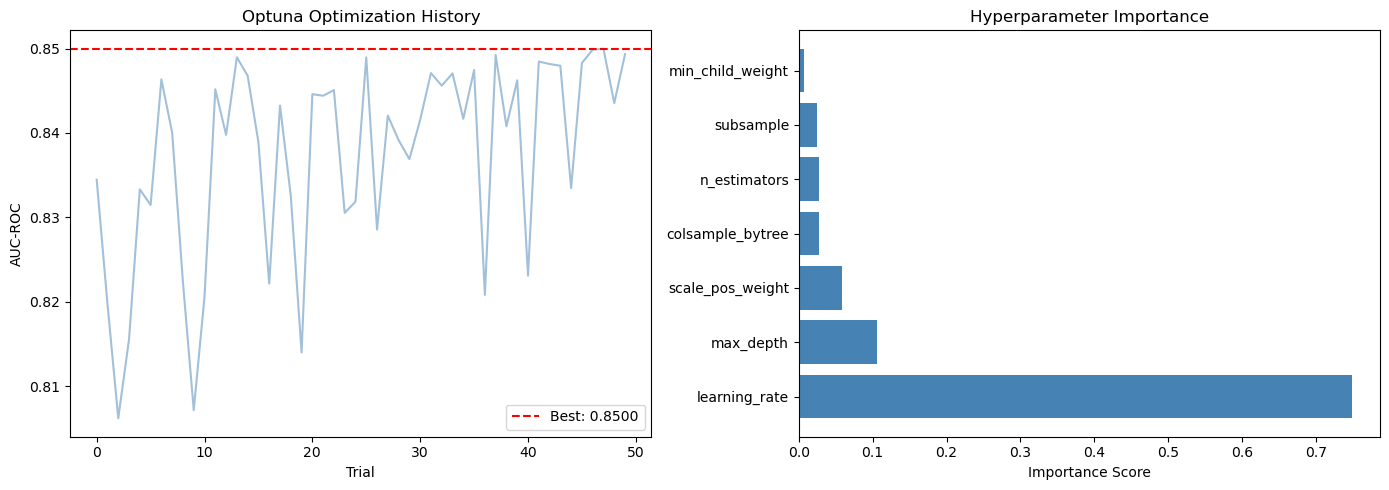

In [7]:
import matplotlib.pyplot as plt

# Plot optimization history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimization history
trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'], 
             alpha=0.5, color='steelblue')
axes[0].axhline(y=study.best_value, color='red', 
                linestyle='--', label=f'Best: {study.best_value:.4f}')
axes[0].set_title('Optuna Optimization History')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('AUC-ROC')
axes[0].legend()

# Parameter importance
param_importance = optuna.importance.get_param_importances(study)
axes[1].barh(list(param_importance.keys()), 
             list(param_importance.values()),
             color='steelblue')
axes[1].set_title('Hyperparameter Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [9]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost Baseline', 
              'Random Forest', 'XGBoost Tuned'],
    'AUC-ROC': [0.8477, 0.8411, 0.8230, 
                round(metrics['auc_roc'], 4)],
    'Recall': [0.7834, 0.7727, 0.4733, 
               round(metrics['recall'], 4)],
    'F1': [0.6162, 0.6262, 0.5339, 
           round(metrics['f1'], 4)]
})

print(results.to_string(index=False))
print(f"\n Improvement over baseline: "
      f"+{(metrics['auc_roc'] - 0.8411):.4f} AUC-ROC")

              Model  AUC-ROC  Recall     F1
Logistic Regression   0.8477  0.7834 0.6162
   XGBoost Baseline   0.8411  0.7727 0.6262
      Random Forest   0.8230  0.4733 0.5339
      XGBoost Tuned   0.8487  0.5107 0.5744

 Improvement over baseline: +0.0076 AUC-ROC
